In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import Dense

from tensorflow.keras.datasets import mnist

from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline


from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


I0000 00:00:1789112697.540804   20336 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789112697.541341   20336 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789112697.578710   20336 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789112701.292047   20336 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [3]:
BACK_C = (.12, .12, .12, 1.)
plt.style.use('dark_background')


In [4]:
params = {'figure.facecolor': BACK_C,
          'axes.facecolor': BACK_C,
          'axes.titleweight': 'bold'}

plt.rcParams.update(params)


In [5]:
def plot_sample(X: np.array, y: np.array) -> None:
    # generate 12 random index to select imgs
    idxs = np.random.randint(0, X.shape[0], 12)

    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(idxs):
        plt.subplot(3, 4, i+1)
        plt.title(y[idx])
        plt.imshow(X[idx], cmap='gray')
    plt.tight_layout()
    plt.show()


def get_model(n_class: int, activation: str = 'relu') -> tf.keras.Sequential:
    # Sequential model take a list of layers
    model = tf.keras.Sequential([
        Dense(units=50, activation=activation),  # first layer with 50 neurons
        Dense(units=50, activation=activation),

        # transform output in probabilities
        # n_neurons = n_class
        Dense(units=n_class, activation='softmax')
    ])

    # set an optimizer and a loss
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


def plot_lc(history: dict, metrics: list = ['loss', 'accuracy']) -> None:
    plt.figure(figsize=(20, 8))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.title(f'Learning curve for {metric}\n')
        plt.plot(history[metric], label='train')
        plt.plot(history[f'val_{metric}'], label='val')
        plt.xlabel('epochs')
        plt.ylabel(metric)
        plt.legend()
    plt.show()


def plot_cm(y_true: np.array, y_pred: np.array) -> None:
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(20, 8))
    plt.title('Confusion Matrix\n')
    sns.heatmap(cm, cmap='vlag', annot=True, fmt='d', cbar=False)
    plt.xlabel('y_pred')
    plt.ylabel('y_true')
    plt.show()


# Load Data


In [6]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

#60k imgs with 28 pixels by 28 pixels
X_train.shape


(60000, 28, 28)

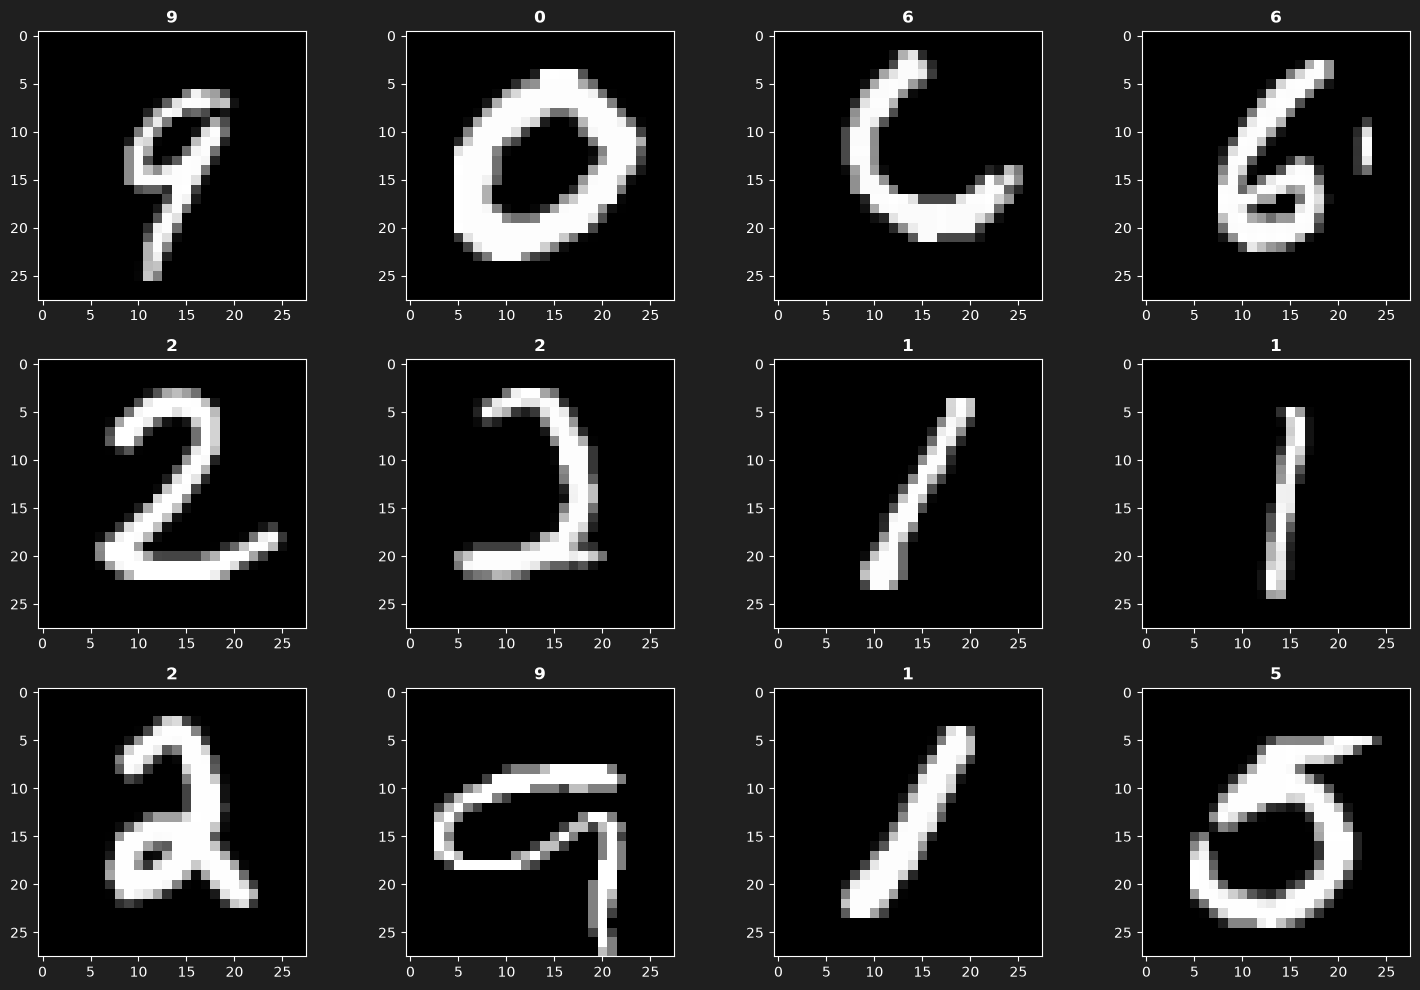

In [7]:
plot_sample(X_train, y_train)

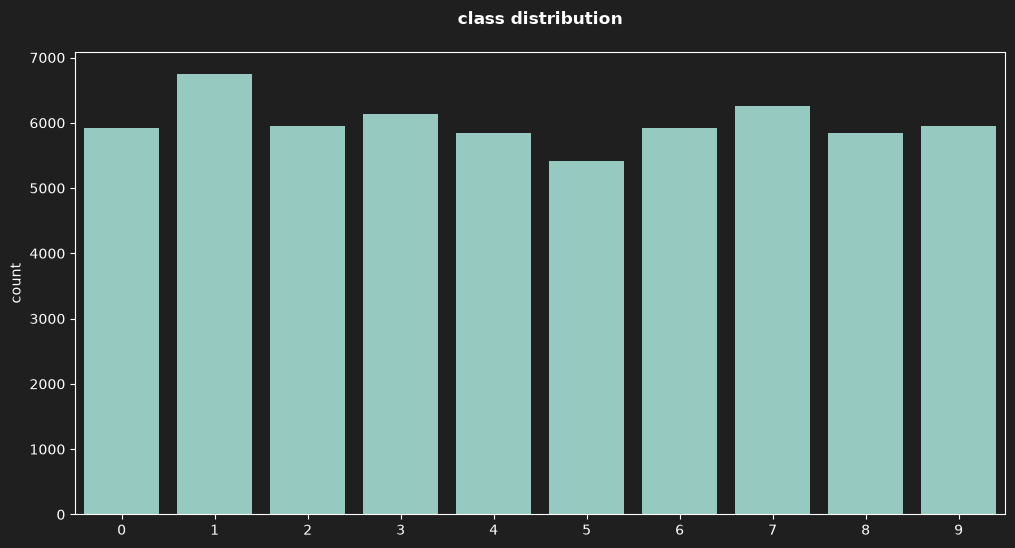

array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949])

In [8]:
plt.figure(figsize=(12, 6))
plt.title('class distribution\n')
sns.countplot(x=y_train)
plt.show()

_, count = np.unique(y_train, return_counts=True)
count


# Préparation images et model

>Il faut absolument transformer chacune de nos images en un vecteur.
>
>i.e. tous les pixels les uns à côté des autres.
>
>Pour rapppel, chaque pixel jouera le rôle de feature

In [10]:


print('X_train: ', X_train.shape)
X_train = X_train.reshape(-1, 28*28)
print('X_train: ', X_train.shape)
X_test = X_test.reshape(-1, 28*28)


X_train:  (60000, 784)
X_train:  (60000, 784)


In [9]:
model = get_model(np.unique(y_train).shape[0])

model.fit(X_train, y_train, epochs=20,
          batch_size=100, validation_split=0.2)


Epoch 1/20
480/480 [==============================] - 2s 2ms/step - loss: 2.9418 - accuracy: 0.7113 - val_loss: 0.7090 - val_accuracy: 0.8323
Epoch 2/20
480/480 [==============================] - 1s 2ms/step - loss: 0.5742 - accuracy: 0.8559 - val_loss: 0.4873 - val_accuracy: 0.8830
Epoch 3/20
480/480 [==============================] - 1s 2ms/step - loss: 0.4203 - accuracy: 0.8918 - val_loss: 0.3815 - val_accuracy: 0.9073
Epoch 4/20
480/480 [==============================] - 1s 2ms/step - loss: 0.3428 - accuracy: 0.9086 - val_loss: 0.3597 - val_accuracy: 0.8999
Epoch 5/20
480/480 [==============================] - 1s 2ms/step - loss: 0.2964 - accuracy: 0.9217 - val_loss: 0.3143 - val_accuracy: 0.9227
Epoch 6/20
480/480 [==============================] - 1s 2ms/step - loss: 0.2682 - accuracy: 0.9277 - val_loss: 0.3104 - val_accuracy: 0.9284
Epoch 7/20
480/480 [==============================] - 1s 2ms/step - loss: 0.2431 - accuracy: 0.9349 - val_loss: 0.3022 - val_accuracy: 0.9255
Epoch 

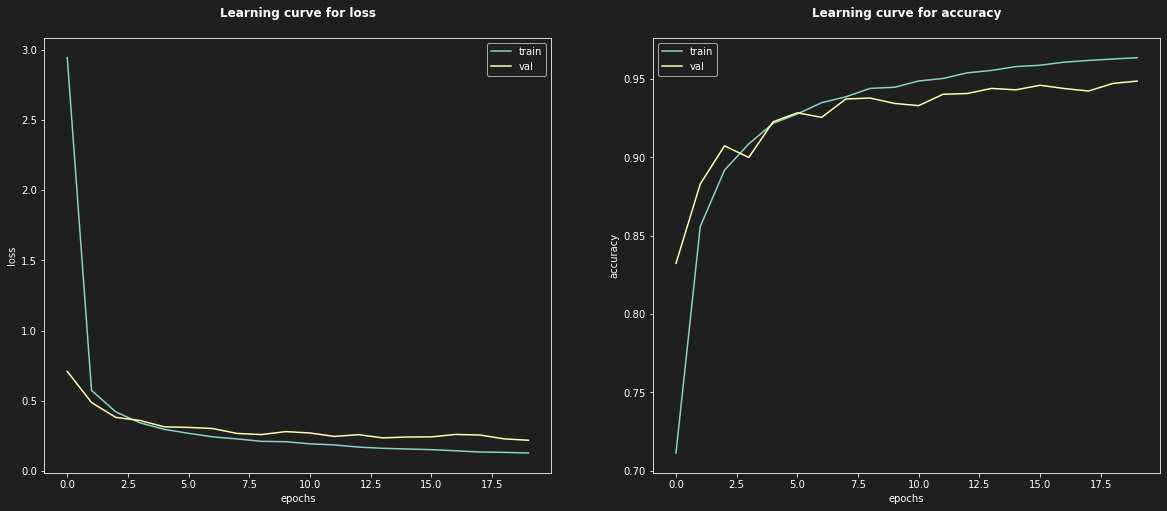

In [10]:
# fetch a dictionnary with the history of the training to plot learning curves
plot_lc(model.history.history)

# Prédictions

In [11]:
y_pred = model.predict(X_test)
y_pred.shape


(10000, 10)

>La dernière couche de notre modèle renvoie 10 valeurs. Chaque valeur représentant
>
>la probabilité associée à chacune des classes.
>
>Pour retrouver la classe prédite, il suffit de retrouver l'index de la colonne avec la probabilité la plus élevée.

In [12]:
y_pred = np.argmax(y_pred, axis=1)
y_pred.shape


(10000,)

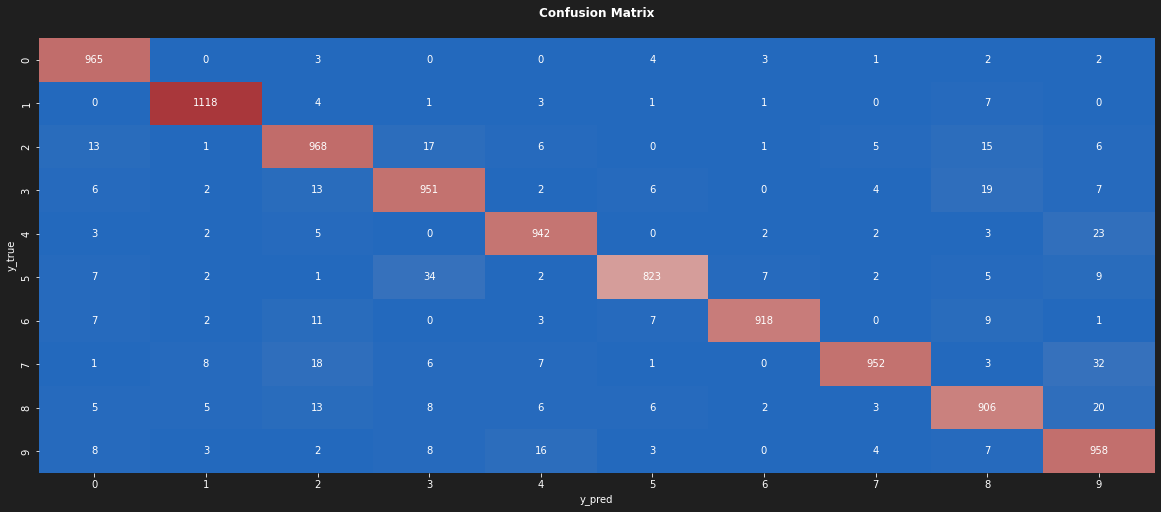

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.98      0.99      0.98      1135
           2       0.93      0.94      0.94      1032
           3       0.93      0.94      0.93      1010
           4       0.95      0.96      0.96       982
           5       0.97      0.92      0.94       892
           6       0.98      0.96      0.97       958
           7       0.98      0.93      0.95      1028
           8       0.93      0.93      0.93       974
           9       0.91      0.95      0.93      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



In [13]:
plot_cm(y_test, y_pred)
print(classification_report(y_test, y_pred))


# Affichons quelques erreurs

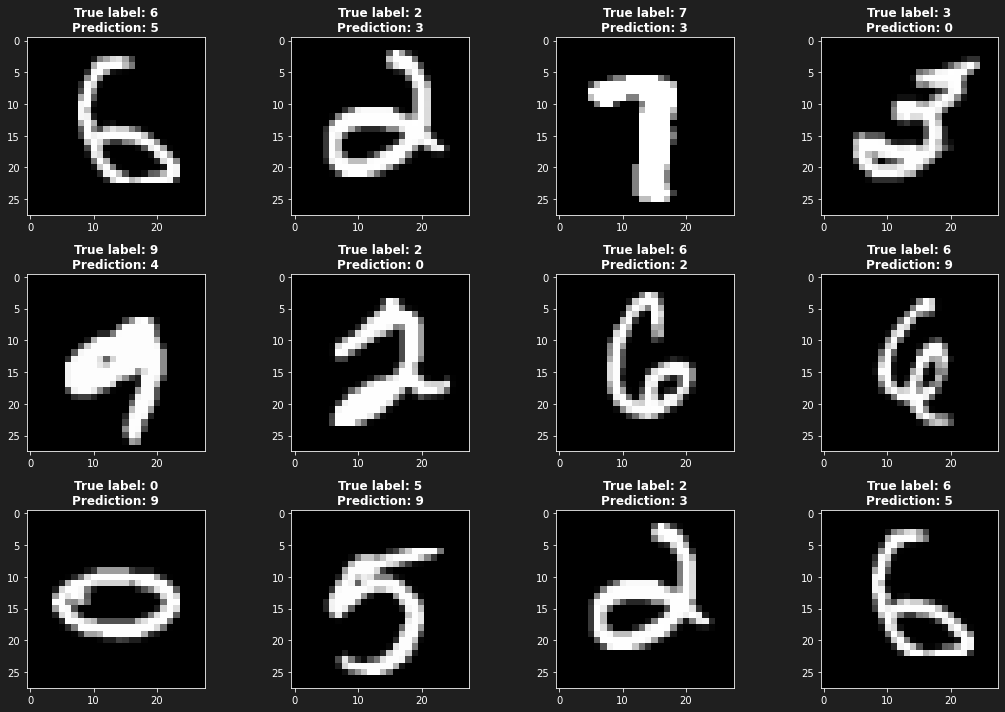

In [14]:
# imgs where y_test != y_pred i.e. an error
errors = X_test[y_pred != y_test]
errors = errors.reshape(-1, 28, 28)

# get the wrong label predictions
y_pred_false = y_pred[y_pred != y_test]
# get the true label where the predictions are wrong
y_pred_true = y_test[y_pred != y_test]

idxs = np.random.randint(0, errors.shape[0], 12)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(idxs):
    plt.subplot(3, 4, i+1)
    plt.title(f'True label: {y_pred_true[idx]}\nPrediction: {y_pred_false[idx]}')
    plt.imshow(errors[idx], cmap='gray')
plt.tight_layout()
plt.show()


# Comparons avec un arbre de décision

>Ici nous utilisons au préalable une PCA afin de réduire la dimensionalité et réduire le bruit.
>
>784 features pour un arbre de décision, c'est trop. Le temps d'entraînement serait trop long et le performance faible/
>
>On ne prendra pas le temps de vérifier exactement la quantité de composantes à conserver.

<br>

In [15]:
dt = make_pipeline(PCA(n_components=50),
                   DecisionTreeClassifier(random_state=1))

params = {'decisiontreeclassifier__max_depth': np.arange(10, 31, 5)}


grid = GridSearchCV(dt, param_grid=params, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)


GridSearchCV(estimator=Pipeline(steps=[('pca', PCA(n_components=50)),
                                       ('decisiontreeclassifier',
                                        DecisionTreeClassifier(random_state=1))]),
             n_jobs=-1,
             param_grid={'decisiontreeclassifier__max_depth': array([10, 15, 20, 25, 30])},
             scoring='accuracy')

In [16]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_decisiontreeclassifier__max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,10.293026,0.185873,0.078000,0.002608,10,{'decisiontreeclassifier__max_depth': 10},0.791500,0.787000,0.783500,0.784417,0.796417,0.788567,0.004808,5
1,11.351230,0.191535,0.082600,0.003826,15,{'decisiontreeclassifier__max_depth': 15},0.840250,0.832167,0.829250,0.831250,0.845083,0.835600,0.006043,2
2,11.949014,0.126721,0.066864,0.004797,20,{'decisiontreeclassifier__max_depth': 20},0.838250,0.836417,0.828333,0.830083,0.845667,0.835750,0.006199,1
3,12.396776,0.086002,0.059743,0.002550,25,{'decisiontreeclassifier__max_depth': 25},0.832083,0.831333,0.830083,0.829750,0.844250,0.833500,0.005441,3
4,11.204794,2.716150,0.058510,0.004852,30,{'decisiontreeclassifier__max_depth': 30},0.834333,0.830667,0.826917,0.828083,0.843500,0.832700,0.005970,4


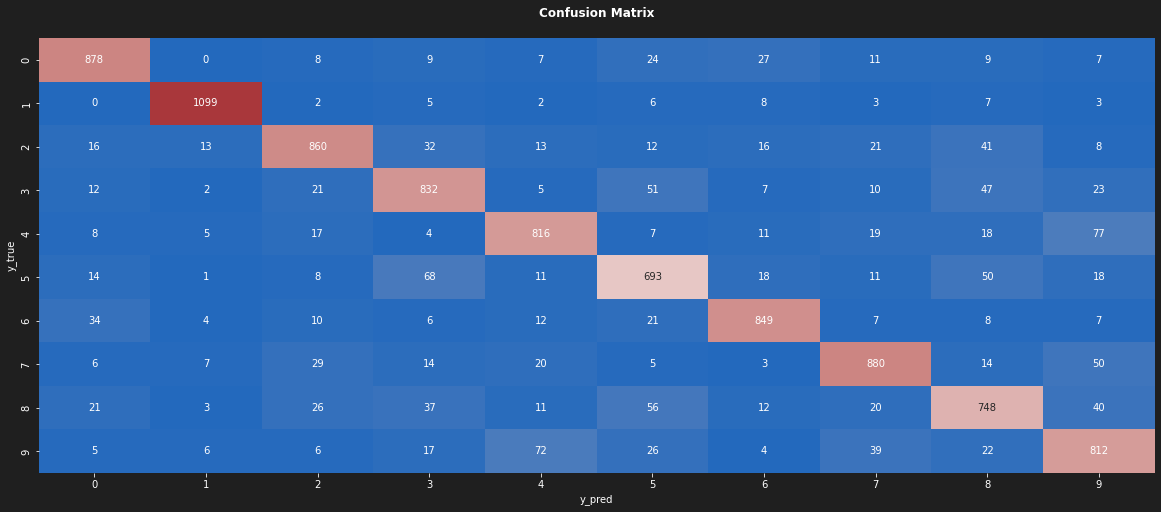

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       980
           1       0.96      0.97      0.97      1135
           2       0.87      0.83      0.85      1032
           3       0.81      0.82      0.82      1010
           4       0.84      0.83      0.84       982
           5       0.77      0.78      0.77       892
           6       0.89      0.89      0.89       958
           7       0.86      0.86      0.86      1028
           8       0.78      0.77      0.77       974
           9       0.78      0.80      0.79      1009

    accuracy                           0.85     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.85      0.85      0.85     10000



In [17]:
dt = grid.best_estimator_

y_pred = dt.predict(X_test)

plot_cm(y_test, y_pred)
print(classification_report(y_test, y_pred))